In [16]:
import torch
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


In [17]:
#hyper parameters for the model training

batch_size = 64
epochs = 35
lr = 0.005          #--------> Learning Rate for adam optimizer
l2_value = 0.0005    #------> l2 regulerization
label_smoothing = 0.0     #--> Value is ignoreerd (just used it for testing)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
torch.backends.cudnn.benchmark = True

Using device: cuda


In [18]:
# data augmentation for the training set

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = v2.Compose([
    v2.RandomCrop(32, padding=4),        # pad by 4 pixels, then crop a random 32x32 piece
    v2.RandomHorizontalFlip(p=0.5),      # mirror the image half the time
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean, std)])

test_transform = v2.Compose([            # no augmentation done here for testing data
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean, std)])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)


In [19]:
# -------- model  with a deep convoloution layers

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)


#also useed batch nomaliztion and dropout layers

        # block 1
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(64)
        self.drop1 = nn.Dropout(0.1)

        # block 2
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(128)
        self.drop2 = nn.Dropout(0.2)

        # block 3
        self.conv5 = nn.Conv2d(128, 256, 3, padding=1, bias=False)
        self.bn5 = nn.BatchNorm2d(256)
        self.conv6 = nn.Conv2d(256, 256, 3, padding=1, bias=False)
        self.bn6 = nn.BatchNorm2d(256)
        self.drop3 = nn.Dropout(0.3)

        # classifier
        self.drop_fc = nn.Dropout(0.4)
        self.fc = nn.Linear(256 * 4 * 4, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.drop1(self.pool(x))                        # -----> 64x16x16

        x = F.relu(self.bn3(self.conv3(x)))                 # -----> 128x16x16
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.drop2(self.pool(x))                        # -----> 128x8x8

        x = F.relu(self.bn5(self.conv5(x)))                 # ----> 256x8x8
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.drop3(self.pool(x))                        # ------> 256x4x4

        x = torch.flatten(x, 1)                             #--------> 256*4*4 = 4096
        x = self.drop_fc(x)
        x = self.fc(x)
        return x


net = Net().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4, nesterov=True)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, epochs=epochs, steps_per_epoch=len(trainloader))

In [20]:

# ---------------- training ----------------
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    # train
    net.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)


        # l1_lambda = 1e-6     # L1 regularization:
        # loss = loss + l1_lambda * sum(p.abs().sum() for p in net.parameters())

        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * labels.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = 100 * correct / total

    # validation process
    net.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            val_loss_sum += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = 100 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f'Epoch [{epoch + 1}/{epochs}] '
          f'train loss: {train_loss:.3f}, train acc: {train_acc:.2f}% | '
          f'val loss: {val_loss:.3f}, val acc: {val_acc:.2f}%')

print('Finished Training')
print(f'Final val acc: {val_accs[-1]:.2f}% | Best val acc: {max(val_accs):.2f}%')


Epoch [1/35] train loss: 1.743, train acc: 37.67% | val loss: 1.463, val acc: 48.75%
Epoch [2/35] train loss: 1.381, train acc: 50.32% | val loss: 1.086, val acc: 61.93%
Epoch [3/35] train loss: 1.184, train acc: 58.50% | val loss: 1.017, val acc: 65.02%
Epoch [4/35] train loss: 1.072, train acc: 62.80% | val loss: 0.830, val acc: 71.24%
Epoch [5/35] train loss: 0.955, train acc: 66.65% | val loss: 0.954, val acc: 68.53%
Epoch [6/35] train loss: 0.868, train acc: 69.77% | val loss: 0.730, val acc: 74.59%
Epoch [7/35] train loss: 0.795, train acc: 72.46% | val loss: 0.742, val acc: 74.47%
Epoch [8/35] train loss: 0.735, train acc: 74.65% | val loss: 0.732, val acc: 74.20%
Epoch [9/35] train loss: 0.683, train acc: 76.50% | val loss: 0.643, val acc: 77.91%
Epoch [10/35] train loss: 0.637, train acc: 78.00% | val loss: 0.754, val acc: 74.30%
Epoch [11/35] train loss: 0.600, train acc: 78.98% | val loss: 0.684, val acc: 77.36%
Epoch [12/35] train loss: 0.571, train acc: 80.36% | val loss: 

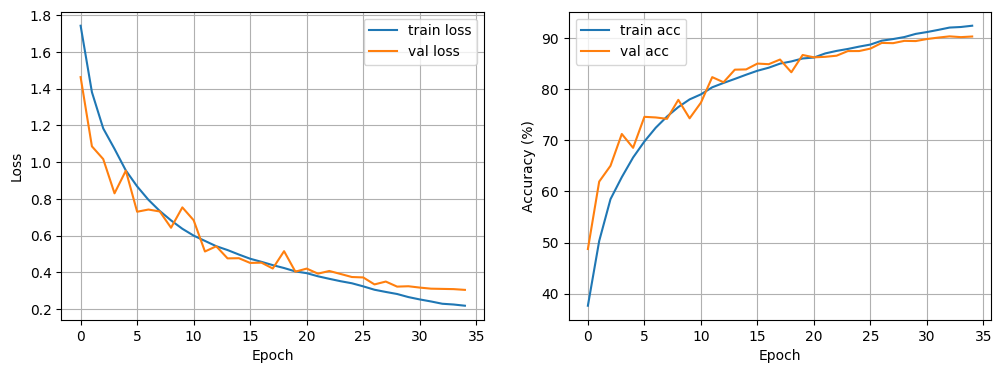

In [21]:

# ---------------- plots ----------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train loss')
plt.plot(val_losses, label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='train acc')
plt.plot(val_accs, label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid()
plt.show()



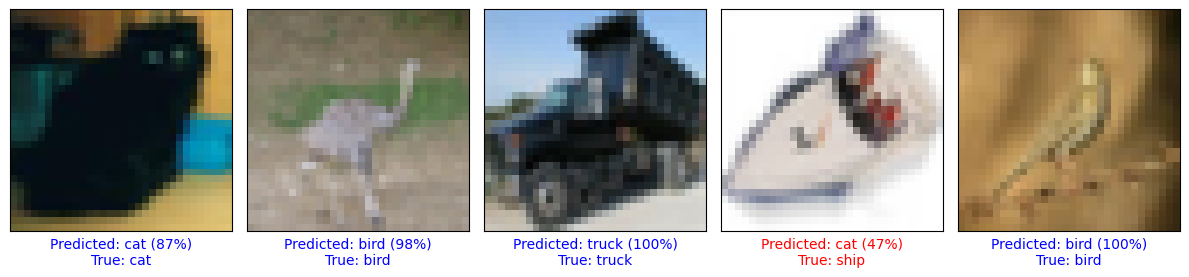

In [22]:

# ---------------- predictions on 5 random test images ----------------
class_names = ['plane', 'car', 'bird', 'cat',
               'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

net.eval()
idx = torch.randperm(len(testset))[:5]               # 5 random test indices (different every run)
test_images = torch.stack([testset[i][0] for i in idx])
test_labels = torch.tensor([testset[i][1] for i in idx])

with torch.no_grad():
    outputs = net(test_images.to(device))
    predictions = F.softmax(outputs, dim=1).cpu()     # probabilities, shape (5, 10)


def plot_image(i, predictions_array, true_label, img, class_names):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    plt.grid(False)

    plt.xticks([])
    plt.yticks([])

    img = img * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)   # undo Normalize
    plt.imshow(img.clamp(0, 1).permute(1, 2, 0).numpy())

    predicted_label = predictions_array.argmax().item()
    color = 'blue' if predicted_label == true_label.item() else 'red'

    plt.xlabel(f"Predicted: {class_names[predicted_label]} "
               f"({100 * predictions_array.max():.0f}%)\n"
               f"True: {class_names[true_label.item()]}",
               color=color)


plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plot_image(i, predictions, test_labels, test_images, class_names)
plt.tight_layout()
plt.show()
